# PanDerm 모델 리뷰: 아키텍처 & 파이프라인 상세 분석

**목적**: PanDerm Foundation Model의 실제 사용 방법과 Linear Evaluation 파이프라인 전체 흐름을 상세히 정리합니다.

**분석 항목**:
1. 모델 아키텍처 개요 (ViT-L/16 기반)
2. 전처리 파이프라인 (이미지 → 피처 벡터)
3. Linear Probe 학습 메커니즘 (LogisticRegression + LBFGS)
4. 파라미터 카운트 및 계산 복잡도
5. 평가 지표 계산 방식
6. 현재 구현의 알려진 한계점
7. 개선 가능 방향

In [1]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from functools import partial

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = (NOTEBOOK_DIR / "../..").resolve()
CLASSIFICATION_DIR = PROJECT_ROOT / "PanDerm" / "classification"

if str(CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(CLASSIFICATION_DIR))

print(f"Project root     : {PROJECT_ROOT}")
print(f"Classification   : {CLASSIFICATION_DIR}")
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")

Project root     : /home/junkim/paper_ajou_dev
Classification   : /home/junkim/paper_ajou_dev/PanDerm/classification
PyTorch version  : 2.5.1+cu121
CUDA available   : True


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 (NanumGothic — matplotlib 내장)
_nanum_path = Path(matplotlib.__file__).parent / "mpl-data" / "fonts" / "ttf" / "NanumGothic.ttf"
if _nanum_path.exists():
    fm.fontManager.addfont(str(_nanum_path))
    matplotlib.rc("font", family="NanumGothic")
else:
    print(f"[경고] NanumGothic.ttf 를 찾을 수 없습니다: {_nanum_path}")

matplotlib.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
print(f"Font: {matplotlib.rcParams['font.family']}")

Font: ['NanumGothic']


## 1. 모델 아키텍처 개요

### 1-1. 전체 구조 다이어그램

```
PanDerm Foundation Model (Linear Probe 용도)
════════════════════════════════════════════════════════

입력 이미지 (3 × 224 × 224)
        │
        ▼
┌─────────────────────────────┐
│  Patch Embedding            │
│  (16×16 패치, 196개 → 197토큰)│  ← CLS 토큰 추가
└─────────────────────────────┘
        │
        ▼
┌─────────────────────────────┐
│  Sinusoidal 2D Position     │
│  Embedding (고정, 학습 안함)  │
└─────────────────────────────┘
        │
        ▼  × 24번 반복 (Large) / × 12번 (Base)
┌─────────────────────────────┐
│  Transformer Block          │
│  - Multi-Head Self-Attention│  ← Relative Position Bias
│  - Feed-Forward Network     │
│  - LayerNorm (Pre-Norm)     │
│  - DropPath                 │
└─────────────────────────────┘
        │
        ▼
┌─────────────────────────────┐
│  LayerNorm (마지막)          │
└─────────────────────────────┘
        │
        ▼  [Linear Probe 모드]
┌─────────────────────────────┐
│  CLS 토큰 추출               │  → 1024-dim 피처 벡터
└─────────────────────────────┘

════════════════════════════════════════════════════════
                    ↓
    Linear Probe (LogisticRegression, LBFGS)
                    ↓
         예측 확률 (7-class softmax)
```

### 1-2. 모델 변형 비교표

| 항목 | PanDerm_Large_LP | PanDerm_Base_LP |
|------|------------------|-----------------|
| 아키텍처 | ViT-L/16 | ViT-B/16 |
| 임베딩 차원 (`embed_dim`) | **1024** | 768 |
| Transformer 블록 수 (`depth`) | **24** | 12 |
| 어텐션 헤드 수 (`num_heads`) | **16** | 12 |
| MLP 비율 (`mlp_ratio`) | 4 | 4 |
| 입력 이미지 크기 | 224×224 | 224×224 |
| 패치 크기 | 16×16 | 16×16 |
| 패치 수 | 196 (14×14) | 196 (14×14) |
| 피처 벡터 차원 | **1024** | 768 |
| 체크포인트 | `panderm_ll_data6_checkpoint-499.pth` | `panderm_bb_data6_checkpoint-499.pth` |

> **현재 사용 중인 모델**: `PanDerm_Large_LP` (ViT-L/16, 1024-dim)

In [3]:
from models.modeling_finetune import panderm_large_patch16_224, VisionTransformer

# 가중치 로딩 없이 구조만 확인 (체크포인트 없어도 실행 가능)
model = panderm_large_patch16_224()

# 파라미터 수 계산
total_params  = sum(p.numel() for p in model.parameters())
train_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 55)
print("  PanDerm Large (ViT-L/16) 모델 구조")
print("=" * 55)
print(f"  총 파라미터 수  : {total_params:,} ({total_params/1e6:.1f}M)")
print(f"  학습 가능 파라미터: {train_params:,} ({train_params/1e6:.1f}M)")
print()
print(f"  embed_dim       : {model.embed_dim}")
print(f"  depth (blocks)  : {len(model.blocks)}")
print(f"  patch_embed     : {model.patch_embed}")
print(f"  cls_token shape : {model.cls_token.shape}")
print(f"  pos_embed shape : {model.pos_embed.shape}")
print(f"  head            : {model.head}")

/home/junkim/miniconda3/envs/paper/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/junkim/miniconda3/envs/paper/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/junkim/miniconda3/envs/paper/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


  PanDerm Large (ViT-L/16) 모델 구조
  총 파라미터 수  : 304,351,208 (304.4M)
  학습 가능 파라미터: 304,149,480 (304.1M)

  embed_dim       : 1024
  depth (blocks)  : 24
  patch_embed     : PatchEmbed(
  (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
)
  cls_token shape : torch.Size([1, 1, 1024])
  pos_embed shape : torch.Size([1, 197, 1024])
  head            : Linear(in_features=1024, out_features=1000, bias=True)


In [4]:
# Transformer 블록 상세 구조 (첫 번째 블록)
print("첫 번째 Transformer 블록 구조:")
print("-" * 50)
print(model.blocks[0])

# 각 블록의 파라미터 수
block_params = sum(p.numel() for p in model.blocks[0].parameters())
print(f"\n블록당 파라미터 수: {block_params:,} ({block_params/1e6:.2f}M)")
print(f"전체 블록 총 파라미터: {block_params * 24:,} ({block_params * 24/1e6:.1f}M)")

첫 번째 Transformer 블록 구조:
--------------------------------------------------
Block(
  (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=1024, out_features=3072, bias=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (proj): Linear(in_features=1024, out_features=1024, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (drop_path): Identity()
  (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=1024, out_features=4096, bias=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=4096, out_features=1024, bias=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
)

블록당 파라미터 수: 12,597,248 (12.60M)
전체 블록 총 파라미터: 302,333,952 (302.3M)


## 2. 전처리 파이프라인

```
원본 이미지 (임의 해상도, RGB)
        │
        ▼  transforms.Resize(256)
단변 256px으로 리사이즈 (비율 유지)
        │
        ▼  transforms.CenterCrop(224)
중앙 224×224 크롭
        │
        ▼  transforms.ToTensor()
Tensor 변환 (값 범위: [0, 1])
        │
        ▼  transforms.Normalize(ImageNet mean/std)
ImageNet 정규화
        mean = (0.485, 0.456, 0.406)
        std  = (0.228, 0.224, 0.225)
        │
        ▼
최종 입력: FloatTensor (3 × 224 × 224)
```

> **주의**: `std` 값이 표준 ImageNet(0.229, 0.224, 0.225)과 약간 다름 — PanDerm 사전학습 시 사용한 커스텀 정규화 값

In [5]:
from models.builder import get_eval_transforms
from torchvision import transforms

eval_transform = get_eval_transforms(which_img_norm='imagenet', img_resize=256, center_crop=True)
print("현재 사용 중인 전처리 파이프라인:")
print(eval_transform)

# 더미 입력으로 출력 shape 확인
from PIL import Image
import numpy as np
dummy_img = Image.fromarray(np.random.randint(0, 255, (512, 400, 3), dtype=np.uint8))
dummy_tensor = eval_transform(dummy_img)
print(f"\n더미 이미지 입력 크기: {dummy_img.size} (W×H)")
print(f"전처리 후 텐서 shape  : {dummy_tensor.shape}")
print(f"값 범위 (정규화 후)   : [{dummy_tensor.min():.3f}, {dummy_tensor.max():.3f}]")

normalization method:  imagenet
현재 사용 중인 전처리 파이프라인:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.228, 0.224, 0.225))
)

더미 이미지 입력 크기: (400, 512) (W×H)
전처리 후 텐서 shape  : torch.Size([3, 224, 224])
값 범위 (정규화 후)   : [-1.749, 2.291]


## 3. 피처 추출 흐름 (`forward_features`)

### 핵심 코드 (`modeling_finetune.py:496-527`)

```python
def forward_features(self, x, is_train=True):
    # 1. Patch Embedding: (B, 3, 224, 224) → (B, 196, 1024)
    x = self.patch_embed(x)
    batch_size, seq_len, _ = x.size()  # seq_len = 196

    # 2. CLS 토큰 추가: (B, 197, 1024)
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)

    # 3. 위치 인코딩 추가 (2D Sinusoidal)
    x = x + self.pos_embed.expand(batch_size, -1, -1)
    x = self.pos_drop(x)  # Dropout (eval 시 비활성)

    # 4. 24개 Transformer 블록 통과
    rel_pos_bias = self.rel_pos_bias() if self.rel_pos_bias else None
    for blk in self.blocks:
        x = blk(x, rel_pos_bias=rel_pos_bias)
    x = self.norm(x)  # (B, 197, 1024)

    # 5. Linear Probe 모드 (lin_probe=True 기본값)
    if self.lin_probe:
        if self.linear_type == 'standard':
            return x[:, 0]  # CLS 토큰만 추출 → (B, 1024)
        else:
            # Attentive Probing (현재 비활성)
            ...
```

> **Linear Probing 시 출력**: CLS 토큰의 임베딩 벡터 `x[:, 0]` → shape **(B, 1024)**

In [6]:
# forward_features 출력 shape 검증
model.eval()
device = torch.device("cpu")
model = model.to(device)

dummy_batch = torch.randn(4, 3, 224, 224)  # 배치=4, 3채널, 224×224
with torch.no_grad():
    features = model.forward_features(dummy_batch, is_train=False)

print(f"입력 이미지 shape    : {dummy_batch.shape}")
print(f"피처 출력 shape      : {features.shape}  ← (Batch, EmbedDim)")
print(f"임베딩 차원           : {features.shape[1]} (ViT-L/16 embed_dim)")
print(f"피처 값 범위          : [{features.min():.3f}, {features.max():.3f}]")
print(f"피처 노름(L2) 평균    : {torch.norm(features, dim=1).mean():.3f}")

입력 이미지 shape    : torch.Size([4, 3, 224, 224])
피처 출력 shape      : torch.Size([4, 1024])  ← (Batch, EmbedDim)
임베딩 차원           : 1024 (ViT-L/16 embed_dim)
피처 값 범위          : [-3.152, 3.330]
피처 노름(L2) 평균    : 31.997


## 4. Linear Probe 학습 메커니즘

### 4-1. 전체 구조

```
PanDerm Encoder (완전 동결, requires_grad=False)
        │
        ▼ N개 학습 이미지 → (N, 1024) 피처 행렬
┌─────────────────────────────────────────┐
│   LogisticRegression (PyTorch Linear)  │
│   weight: (1024 × K)  bias: (K,)       │
│   K = 클래스 수                          │
└─────────────────────────────────────────┘
        │
        ▼ LBFGS 최적화
   Loss = CrossEntropyLoss + (1/C) × ||W||²
        │
        ▼ Softmax
   예측 확률 (N, K)
```

### 4-2. 핵심 하이퍼파라미터

| 하이퍼파라미터 | 값 | 설명 |
|---------------|-----|------|
| `C` (역정규화 강도) | `(embed_dim × K) / 100` | Oral_Diseases: `(1024×7)/100 = 71.68` |
| `max_iter` | 1000 | LBFGS 최대 반복 횟수 |
| `optimizer` | LBFGS (Strong Wolfe) | 2차 미분 기반 최적화 |
| `loss` | CrossEntropyLoss + L2 | 클래스 가중치 미적용 |
| `random_state` | 100 | 재현성 시드 |

In [7]:
from panderm_model.downstream.eval_features.logistic_regression import LogisticRegression

# Oral_Diseases 설정으로 Linear Probe 구조 확인
NUM_CLASSES = 7
EMBED_DIM   = 1024  # PanDerm Large
C = (EMBED_DIM * NUM_CLASSES) / 100.0

print(f"데이터셋: Oral_Diseases ({NUM_CLASSES}-class)")
print(f"임베딩 차원: {EMBED_DIM}")
print(f"C (역정규화 강도) = ({EMBED_DIM} × {NUM_CLASSES}) / 100 = {C:.2f}")
print()

lr_model = LogisticRegression(C=C, max_iter=1000, verbose=False, random_state=100)

# 더미 데이터로 fit 후 구조 확인
dummy_feats  = torch.randn(407, EMBED_DIM)   # 407 학습 샘플
dummy_labels = torch.randint(0, NUM_CLASSES, (407,))
lr_model.fit(dummy_feats, dummy_labels)

print("LogisticRegression 구조 (학습 후):")
print(f"  logreg (nn.Linear): {lr_model.logreg}")
print(f"  weight shape      : {lr_model.logreg.weight.shape}  (K × D)")
print(f"  bias shape        : {lr_model.logreg.bias.shape}    (K,)")

lr_params = sum(p.numel() for p in lr_model.logreg.parameters())
print(f"  Linear probe 파라미터 수: {lr_params:,} ({lr_params/1e3:.1f}K)")
print()
print("손실 함수:")
print("  L = CrossEntropyLoss(logits, labels) + (1/C) × ||W||")
print(f"  정규화 강도: 1/C = 1/{C:.2f} = {1/C:.6f}")

데이터셋: Oral_Diseases (7-class)
임베딩 차원: 1024
C (역정규화 강도) = (1024 × 7) / 100 = 71.68

100
LogisticRegression 구조 (학습 후):
  logreg (nn.Linear): Linear(in_features=1024, out_features=7, bias=True)
  weight shape      : torch.Size([7, 1024])  (K × D)
  bias shape        : torch.Size([7])    (K,)
  Linear probe 파라미터 수: 7,175 (7.2K)

손실 함수:
  L = CrossEntropyLoss(logits, labels) + (1/C) × ||W||
  정규화 강도: 1/C = 1/71.68 = 0.013951


In [8]:
# 추론 흐름 검증
dummy_test = torch.randn(54, EMBED_DIM)  # Oral_Diseases 테스트 세트 54개
probs = lr_model.predict_proba(dummy_test)          # softmax 확률
preds = lr_model.predict_proba(dummy_test).argmax(dim=1)  # argmax

print(f"테스트 샘플: {dummy_test.shape}")
print(f"출력 확률 shape: {probs.shape}  (각 행이 7개 클래스 확률, 합=1)")
print(f"예측 레이블: {preds[:10].tolist()} ...")
print(f"확률 합 (첫 샘플): {probs[0].sum():.6f}")

테스트 샘플: torch.Size([54, 1024])
출력 확률 shape: torch.Size([54, 7])  (각 행이 7개 클래스 확률, 합=1)
예측 레이블: [5, 2, 4, 2, 0, 4, 6, 6, 3, 2] ...
확률 합 (첫 샘플): 1.000000


## 5. 평가 지표 계산 방식

(`metrics.py:get_eval_metrics` 기반)

| 지표 | 계산 함수 | 특이사항 |
|------|-----------|----------|
| **Accuracy** | `accuracy_score` | 전체 정분류율 |
| **Balanced Accuracy** | `balanced_accuracy_score` | 클래스별 Recall 산술평균 |
| **Cohen's Kappa** | `cohen_kappa_score(weights='quadratic')` | 우연 보정, 거리 가중 |
| **Weighted F1** | `classification_report['weighted avg']['f1-score']` | Support 가중 평균 |
| **AUROC** | `roc_auc_score(multi_class='ovo', average='macro')` | OvO (one-vs-one) 방식 |
| **AUPR** | `average_precision_score(average='macro')` | OvR (one-vs-rest) 방식 |

### 핵심 주의사항

**AUROC**: OvO(One-vs-One) macro 방식 — 클래스 간 모든 쌍을 이진 분류로 평가 후 평균  
**AUPR**: OvR(One-vs-Rest) macro 방식 — 소수 클래스가 Positive가 될 때 Negative가 과대해져 Precision 급락 → **소수 클래스 존재 시 Macro AUPR이 실제보다 낮게 보임**

In [9]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    cohen_kappa_score, roc_auc_score, average_precision_score,
    classification_report
)

# Oral_Diseases 실제 결과 로드
PRED_CSV = PROJECT_ROOT / "PanDerm" / "output_dir" / "oral_diseases_panderm_large_lp" / "oral_diseases_multiclass.csv"
CLASS_NAMES = ["CaS", "CoS", "Gum", "MC", "OC", "OLP", "OT"]

pred_df = pd.read_csv(PRED_CSV)
y_true  = pred_df["true_label"].values
y_pred  = pred_df["predicted_label"].values
prob_cols = [c for c in pred_df.columns if c.startswith("probability_class_")]
probs   = pred_df[prob_cols].values

print("=" * 55)
print("  Oral_Diseases 평가 지표 상세")
print("=" * 55)
print(f"  테스트 샘플 수  : {len(y_true)}")
print(f"  클래스 수       : {probs.shape[1]}")
print()

acc   = accuracy_score(y_true, y_pred)
bacc  = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
cls_r = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
wf1   = cls_r["weighted avg"]["f1-score"]
auroc = roc_auc_score(y_true, probs, multi_class='ovo', average='macro')
aupr  = average_precision_score(y_true, probs, average='macro')

print(f"  Accuracy         : {acc:.4f}")
print(f"  Balanced Accuracy: {bacc:.4f}  ← Acc - BAcc = {acc-bacc:+.4f}")
print(f"  Cohen's Kappa    : {kappa:.4f}  (quadratic weight)")
print(f"  Weighted F1      : {wf1:.4f}")
print(f"  AUROC (OvO macro): {auroc:.4f}")
print(f"  AUPR  (OvR macro): {aupr:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

  Oral_Diseases 평가 지표 상세
  테스트 샘플 수  : 54
  클래스 수       : 7

  Accuracy         : 0.7778
  Balanced Accuracy: 0.8107  ← Acc - BAcc = -0.0329
  Cohen's Kappa    : 0.9248  (quadratic weight)
  Weighted F1      : 0.7584
  AUROC (OvO macro): 0.9463
  AUPR  (OvR macro): 0.7981

              precision    recall  f1-score   support

         CaS       1.00      0.88      0.93         8
         CoS       1.00      1.00      1.00         8
         Gum       0.70      1.00      0.82         7
          MC       0.75      0.67      0.71         9
          OC       0.67      1.00      0.80         6
         OLP       0.75      0.30      0.43        10
          OT       0.62      0.83      0.71         6

    accuracy                           0.78        54
   macro avg       0.78      0.81      0.77        54
weighted avg       0.79      0.78      0.76        54



## 6. 현재 구현의 알려진 한계점

### 한계점 1: 클래스 가중치(Class Weight) 미적용

**위치**: `logistic_regression.py:12`
```python
self.loss_func = torch.nn.CrossEntropyLoss()  # weight 인자 없음
```
- 모든 클래스 샘플에 동일한 가중치 → 다수 클래스에 편향된 학습
- `aptos2019` (IR=9.36x)에서 심각한 영향, `Oral_Diseases` (IR=1.76x)에서는 경미

### 한계점 2: Validation Set 미활용

**위치**: `linear_eval.py:104`
```python
valid_feats=None,  # ← val set이 있음에도 None 전달
valid_labels=val_labels,
```
- `combine_trainval=True`지만 `valid_feats=None`이므로 val set은 학습에 사용되지 않음
- 407개 train만으로 학습, 55개 val은 완전히 무시됨

### 한계점 3: 고정된 C 값

```python
cost = (train_feats.shape[1] * NUM_C) / 100  # 검색 없음
```
- 데이터셋마다 최적 C가 다를 수 있음
- Cross-validation 기반 C 탐색(grid search) 미적용

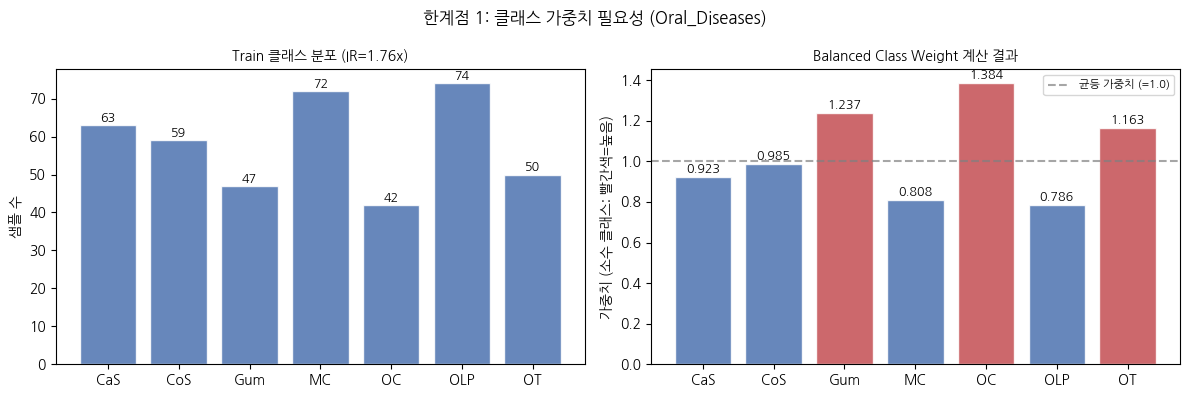


권장 개선 코드:
  class_weights = torch.tensor([0.9229, 0.9855, 1.2371, 0.8075, 1.3844, 0.7857, 1.1629], dtype=torch.float)
  criterion = nn.CrossEntropyLoss(weight=class_weights)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.utils.class_weight import compute_class_weight

# 한계점 1: 클래스 가중치 필요성 시각화
meta_df = pd.read_csv(
    PROJECT_ROOT / "PanDerm" / "data" / "Oral_Diseases" / "Linear Evaluation" / "oral_diseases_multiclass.csv"
)
train_df = meta_df[meta_df["split"] == "train"]
y_train  = train_df["label"].values
classes  = np.arange(NUM_CLASSES)

weights  = compute_class_weight("balanced", classes=classes, y=y_train)
counts   = np.bincount(y_train, minlength=NUM_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("한계점 1: 클래스 가중치 필요성 (Oral_Diseases)", fontsize=12, fontweight="bold")

ax = axes[0]
ax.bar(CLASS_NAMES, counts, color="#4C72B0", alpha=0.85, edgecolor="white")
for i, cnt in enumerate(counts):
    ax.text(i, cnt + 0.3, str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Train 클래스 분포 (IR=1.76x)", fontsize=10)
ax.set_ylabel("샘플 수")

ax2 = axes[1]
bar_colors = ["#C44E52" if w > 1.0 else "#4C72B0" for w in weights]
bars = ax2.bar(CLASS_NAMES, weights, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, w in zip(bars, weights):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{w:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.axhline(1.0, color="gray", ls="--", lw=1.5, alpha=0.7, label="균등 가중치 (=1.0)")
ax2.set_title("Balanced Class Weight 계산 결과", fontsize=10)
ax2.set_ylabel("가중치 (소수 클래스: 빨간색=높음)")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\n권장 개선 코드:")
weights_str = ", ".join([f"{w:.4f}" for w in weights])
print(f"  class_weights = torch.tensor([{weights_str}], dtype=torch.float)")
print(f"  criterion = nn.CrossEntropyLoss(weight=class_weights)")

## 7. 개선 가능 방향

### 7-1. 단기 개선 (현재 Linear Probe 파이프라인 내)

| 개선사항 | 수정 위치 | 기대 효과 |
|----------|-----------|----------|
| **Balanced CrossEntropyLoss** 적용 | `logistic_regression.py:12` | OLP 등 소수 클래스 Recall 향상 |
| **Validation Set 활용** | `linear_eval.py:104` → `valid_feats=val_feats` | val로 C 탐색 또는 조기 종료 |
| **C 하이퍼파라미터 탐색** | `linear_probe.py:train_linear_probe` | 데이터셋별 최적 정규화 강도 |

### 7-2. 중기 개선 (Fine-tuning 또는 데이터 수준)

- **Few-shot Fine-tuning**: OLP와 같이 피처 공간에서 분리가 어려운 클래스에 대해 일부 Transformer 블록 해제 후 소규모 fine-tuning
- **Data Augmentation**: Oral_Diseases 학습 셋 확대 (특히 OLP, MC 클래스)
- **Test-Time Augmentation (TTA)**: Oral_Diseases처럼 테스트 셋이 작을 때 TTA로 예측 안정성 향상

### 7-3. 체크포인트 활용 방식

```python
# builder.py:69-71 (현재 코드)
model = panderm_large_patch16_224()
state_dict = torch.load(args.pretrained_checkpoint, map_location='cpu', weights_only=True)
state_dict = {k.replace("encoder.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)  # strict=False: 불일치 키 무시
```

> `strict=False` 사용 이유: 체크포인트에는 `encoder.` 접두사가 붙어 있어 키를 제거 후 로드. 일부 키(예: head, fc_norm)가 누락되어도 허용.

In [11]:
# 개선안 1: Balanced CrossEntropyLoss 적용 예시
class BalancedLogisticRegression:
    """클래스 가중치를 적용한 개선 버전 (LogisticRegression 대체)."""
    
    def __init__(self, C, num_classes, y_train_numpy, max_iter=1000, seed=100):
        self.C = C
        # 클래스 가중치 자동 계산
        weights = compute_class_weight(
            class_weight='balanced',
            classes=np.arange(num_classes),
            y=y_train_numpy
        )
        weight_tensor = torch.tensor(weights, dtype=torch.float)
        self.loss_func = nn.CrossEntropyLoss(weight=weight_tensor)  # ← 핵심 변경
        self.max_iter = max_iter
        self.seed = seed
        print(f"Balanced Class Weights: {dict(zip(CLASS_NAMES, weights.round(3)))}")

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
demo = BalancedLogisticRegression(C=71.68, num_classes=NUM_CLASSES, y_train_numpy=y_train)

print()
print("# 개선안 2: Validation Set 활용 (linear_eval.py 수정)")
print("""
# 현재 코드
eval_linear_probe(
    train_feats=train_feats,
    train_labels=train_labels,
    valid_feats=None,          # ← 변경 필요
    ...
)

# 개선 코드
eval_linear_probe(
    train_feats=train_feats,
    train_labels=train_labels,
    valid_feats=val_feats,     # ← val 피처 전달
    valid_labels=val_labels,
    combine_trainval=True,     # train+val 합쳐서 최종 학습
    ...
)
""")

Balanced Class Weights: {'CaS': np.float64(0.923), 'CoS': np.float64(0.985), 'Gum': np.float64(1.237), 'MC': np.float64(0.808), 'OC': np.float64(1.384), 'OLP': np.float64(0.786), 'OT': np.float64(1.163)}

# 개선안 2: Validation Set 활용 (linear_eval.py 수정)

# 현재 코드
eval_linear_probe(
    train_feats=train_feats,
    train_labels=train_labels,
    valid_feats=None,          # ← 변경 필요
    ...
)

# 개선 코드
eval_linear_probe(
    train_feats=train_feats,
    train_labels=train_labels,
    valid_feats=val_feats,     # ← val 피처 전달
    valid_labels=val_labels,
    combine_trainval=True,     # train+val 합쳐서 최종 학습
    ...
)



## 8. 전체 파이프라인 요약

```
┌──────────────────────────────────────────────────────────────────────┐
│                  PanDerm Linear Evaluation 전체 파이프라인              │
├──────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  [데이터 로딩]                                                         │
│  CSV metadata → Derm_Dataset → DataLoader                           │
│  (이미지 경로 + 레이블 + split)                                         │
│                    │                                                 │
│  [전처리]           ▼                                                 │
│  Resize(256) → CenterCrop(224) → ToTensor → Normalize(ImageNet)    │
│                    │                                                 │
│  [피처 추출]        ▼                                                 │
│  PanDerm Large (ViT-L/16, 동결)                                      │
│  → forward_features(x, is_train=False)                              │
│  → CLS 토큰 추출 → (N, 1024) numpy float32                           │
│                    │                                                 │
│  [Linear Probe]    ▼                                                 │
│  C = (1024 × K) / 100                                               │
│  LogisticRegression.fit(train_feats, train_labels)                  │
│  LBFGS: Loss = CE + (1/C)×||W||²  (1000 iter)                      │
│                    │                                                 │
│  [평가]            ▼                                                 │
│  predict_proba(test_feats) → softmax 확률                            │
│  → ACC / BACC / Kappa / Weighted F1 / AUROC / AUPR                │
│  → CSV (per-sample predictions) + Confusion Matrix PNG             │
│                                                                      │
└──────────────────────────────────────────────────────────────────────┘
```

### 관련 파일 경로

| 역할 | 경로 |
|------|------|
| 진입점 | `PanDerm/classification/linear_eval.py` |
| 모델 정의 | `PanDerm/classification/models/modeling_finetune.py` |
| 모델 로딩 | `PanDerm/classification/models/builder.py` |
| 피처 추출 | `PanDerm/classification/panderm_model/downstream/extract_features.py` |
| Linear Probe | `PanDerm/classification/panderm_model/downstream/eval_features/linear_probe.py` |
| LogisticRegression | `PanDerm/classification/panderm_model/downstream/eval_features/logistic_regression.py` |
| 평가 지표 | `PanDerm/classification/panderm_model/downstream/eval_features/metrics.py` |
| 데이터셋 | `PanDerm/classification/datasets/derm_data.py` |
| LOO 영향도 분석 | `PanDerm/classification/panderm_model/downstream/sample_influence.py` |